# Lab 4: Data Quality Assessment & Preprocessing

Dataset: 
https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

# Make plots look cleaner
sns.set()
from sklearn.preprocessing import LabelEncoder


In [78]:
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\N\.cache\kagglehub\datasets\austinreese\craigslist-carstrucks-data\versions\10


In [79]:
cars_path = os.path.join(path, 'vehicles.csv') # dataframe path
df = pd.read_csv(cars_path)

print(f"Dataset shape: {df.shape}") #  (426880 rows, 26 columns)
df.head()

Dataset shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


## 2. Data Quality Assessment

In [80]:
# Check data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [81]:
# Select relevant columns
cols = ['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'type']
df=df[cols].copy()

In [82]:
df.dtypes

price             int64
year            float64
manufacturer     object
condition        object
cylinders        object
fuel             object
odometer        float64
transmission     object
type             object
dtype: object

### convert price to float

In [83]:
df['price']=pd.to_numeric(df['price']).astype(float)
df['year'] = pd.to_datetime(df['year'], format='%Y')
df.dtypes

price                  float64
year            datetime64[ns]
manufacturer            object
condition               object
cylinders               object
fuel                    object
odometer               float64
transmission            object
type                    object
dtype: object

## 3. Handling Missing Values

detect missing values 

In [84]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_Percentage': missing_percentage.values
})
missing_data = missing_data[missing_data['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Missing Data Analysis:")
missing_data.head(10)

Missing Data Analysis:


,Column,Missing_Percentage
4,cylinders,41.622470
3,condition,40.785232
8,type,21.752717
2,manufacturer,4.133714
6,odometer,1.030735
5,fuel,0.705819
7,transmission,0.598763
1,year,0.282281


remove missing values

In [85]:
df= df.dropna(subset=['price', 'year', 'odometer']) 
df.isnull().sum()

price                0
year                 0
manufacturer     16267
condition       170493
cylinders       174759
fuel              2172
odometer             0
transmission      1695
type             91782
dtype: int64

fill missing values

In [86]:
# Fill categorical columns with 'unknown', missing means "not specified"
for col in ['manufacturer', 'condition', 'fuel', 'transmission', 'type']:
    df[col] = df[col].fillna('unknown')

# Fill cylinders with mode discrete feature, mode is most representative
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum()) # first sum for each column, second for total sum

Missing values remaining: 0


In [87]:
df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
27,33590.0,2014-01-01,gmc,good,8 cylinders,gas,57923.0,other,pickup
28,22590.0,2010-01-01,chevrolet,good,8 cylinders,gas,71229.0,other,pickup
29,39590.0,2020-01-01,chevrolet,good,8 cylinders,gas,19160.0,other,pickup
30,30990.0,2017-01-01,toyota,good,8 cylinders,gas,41124.0,other,pickup
31,15000.0,2013-01-01,ford,excellent,6 cylinders,gas,128000.0,automatic,truck


# 4. Handling Outliers

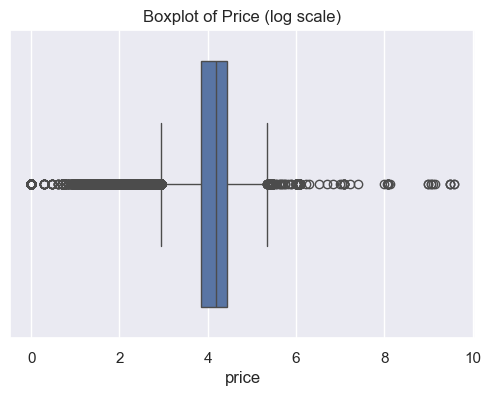

In [88]:
plt.figure(figsize=(6,4))
sns.boxplot(x=np.log10(df['price'][df['price'] > 0]))
plt.title('Boxplot of Price (log scale)')
plt.show()

In [89]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.head(15)

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
204,58977.0,2019-01-01,gmc,unknown,6 cylinders,gas,66368.0,automatic,unknown
280,987654321.0,1960-01-01,chevrolet,unknown,6 cylinders,gas,999999.0,manual,unknown
346,98900.0,2001-01-01,ferrari,good,8 cylinders,gas,20187.0,automatic,convertible
365,72900.0,2021-01-01,chevrolet,good,8 cylinders,gas,19129.0,automatic,SUV
461,99950.0,2021-01-01,chevrolet,unknown,6 cylinders,gas,510.0,automatic,coupe
732,100000.0,1984-01-01,jeep,unknown,6 cylinders,gas,112000.0,manual,unknown
807,63990.0,2017-01-01,unknown,good,6 cylinders,diesel,28400.0,automatic,truck
829,62990.0,2016-01-01,ford,good,8 cylinders,diesel,40193.0,automatic,unknown
857,59990.0,2017-01-01,ford,good,8 cylinders,diesel,31337.0,automatic,truck
906,69950.0,2012-01-01,ford,unknown,6 cylinders,diesel,267001.0,automatic,unknown


remove outliers

In [91]:
df= df[(df['price'] >= lower) & (df['price'] <= upper)]
df.shape

(413421, 9)

 ### Normalize numerical features using both Min-Max and Z-score.

encode categorical cols

In [96]:
categorical_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'transmission', 'type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    # astype(str) bc labelencoder takes string only, we need to ensure no error occur bc of numerical or nan values

df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
27,33590.0,2014-01-01,6,2,6,2,57923.0,2,12
28,22590.0,2010-01-01,40,2,6,2,71229.0,2,12
29,39590.0,2020-01-01,40,2,6,2,19160.0,2,12
30,30990.0,2017-01-01,33,2,6,2,41124.0,2,12
31,15000.0,2013-01-01,5,0,5,2,128000.0,0,2


In [97]:
df.describe()

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
count,413421.000000,413421,413421.000000,413421.000000,413421.000000,413421.000000,4.134210e+05,413421.000000,413421.000000
mean,16390.343858,2011-02-27 11:38:24.588300800,21.462313,3.167660,4.774177,2.039742,9.926506e+04,0.372552,6.323810
min,0.000000,1900-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,5900.000000,2008-01-01 00:00:00,6.000000,1.000000,5.000000,2.000000,3.935900e+04,0.000000,2.000000
50%,13500.000000,2013-01-01 00:00:00,23.000000,2.000000,5.000000,2.000000,8.735900e+04,0.000000,4.000000
75%,25590.000000,2017-01-01 00:00:00,34.000000,6.000000,5.000000,2.000000,1.348500e+05,0.000000,12.000000
max,57112.000000,2022-01-01 00:00:00,42.000000,6.000000,7.000000,5.000000,1.000000e+07,3.000000,13.000000
std,13107.716532,NaN,13.721021,2.465947,0.987838,0.776921,2.151072e+05,0.747725,5.016491


transform

In [105]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['price']].copy()   # keep it as DataFrame (2D)
df_scaled['price'] = scaler.fit_transform(df_scaled[['price']])

df_scaled.head()

,price
27,0.588143
28,0.395539
29,0.693199
30,0.542618
31,0.262642


In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['cylinders', 'odometer']].copy()

df_standardized[['cylinders', 'odometer']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,cylinders,odometer
27,1.240917,-0.192193
28,1.240917,-0.130335
29,1.240917,-0.372396
30,1.240917,-0.270289
31,0.228604,0.133584


PCA

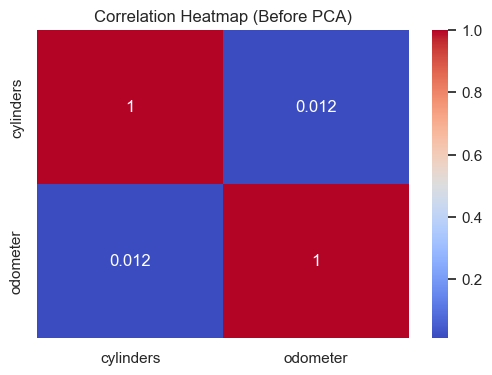

In [109]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['cylinders', 'odometer']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [110]:
from sklearn.decomposition import PCA

X = df_standardized[['cylinders', 'odometer']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50609771 0.49390229]


Feature Engineering

In [44]:
# Car age: older cars typically worth less
df_clean['age'] = 2026 - df_clean['year']

# Mileage per year: high usage = more wear
df_clean['miles_per_year'] = df_clean['odometer'] / (df_clean['age'])


# Interaction: captures combined effect of age and annual mileage
df_clean['age_x_miles_per_year'] = df_clean['miles_per_year'] * df_clean['age']

# Quick preview of engineered features
df_clean[['year', 'age', 'odometer', 'miles_per_year', 'age_x_miles_per_year']].head()

,year,age,odometer,miles_per_year,age_x_miles_per_year
27,2014.0,12.0,57923.0,4826.916667,57923.0
28,2010.0,16.0,71229.0,4451.812500,71229.0
29,2020.0,6.0,19160.0,3193.333333,19160.0
30,2017.0,9.0,41124.0,4569.333333,41124.0
31,2013.0,13.0,128000.0,9846.153846,128000.0
